# Importarção de bibliotecas, configuração e carregamento do dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
'''
Usei o parâmetro decimal porque existem algumas colunas mal formatadas com ',' ao invés de '.'. A função read_csv do pandas tem o decimal, passando ',' como argumento
a engine vai entender que isso deveria ser um '.' é vai formatar.
'''
df = pd.read_csv(
    'dados_reduzidos.csv',
    sep=';',
    decimal=',',
)
df.head()

,id,valor_total,area_util,quartos,vagas,valor_condominio,suites,banheiros,piscina,academia,...,bairro,qtd_dados_bairro,media_idh,expectativa_vida,renda_percapita,estacao_prox,linha_prox,dist,lat,lon
0,526,189900,32,2,1,180.0,0,1,0,1,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,SÃO MATEUS,PRATA,6822.823684,-23.583879,-46.417548
1,734,221110,43,2,1,250.0,0,1,0,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4682.709841,-23.543535,-46.425492
2,738,219990,43,1,1,300.0,0,1,1,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
3,753,219990,43,2,1,300.0,0,1,1,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
4,924,220000,41,2,1,300.0,0,1,1,1,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,3313.918703,-23.557799,-46.443523


In [3]:
df.info() #existem 2499 linhas, 22 colunas e não existem valores nulos

<class 'pandas.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2499 non-null   int64  
 1   valor_total       2499 non-null   int64  
 2   area_util         2499 non-null   int64  
 3   quartos           2499 non-null   int64  
 4   vagas             2499 non-null   int64  
 5   valor_condominio  2264 non-null   float64
 6   suites            2499 non-null   int64  
 7   banheiros         2499 non-null   int64  
 8   piscina           2499 non-null   int64  
 9   academia          2499 non-null   int64  
 10  quadra            2499 non-null   int64  
 11  link              2499 non-null   str    
 12  bairro            2499 non-null   str    
 13  qtd_dados_bairro  2492 non-null   float64
 14  media_idh         2499 non-null   float64
 15  expectativa_vida  2499 non-null   float64
 16  renda_percapita   2499 non-null   float64
 17  estaca

In [4]:
df.describe()

,id,valor_total,area_util,quartos,vagas,valor_condominio,suites,banheiros,piscina,academia,quadra,qtd_dados_bairro,media_idh,expectativa_vida,renda_percapita,dist,lat,lon
count,2499.000000,2.499000e+03,2499.000000,2499.000000,2499.000000,2264.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000,2492.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000
mean,1290.477791,5.480852e+05,71.316927,2.276911,1.226491,1720.326413,0.647459,1.742297,0.370948,0.165266,0.306523,21.928973,0.792821,77.035595,1583.835864,2850.631882,-23.564247,-46.615783
std,740.952704,5.544487e+05,44.756816,0.628384,1.077428,28048.547320,0.805409,1.022180,0.483155,0.371495,0.461142,9.753988,0.057991,2.270557,1108.707809,2740.544877,0.067111,0.101202
min,1.000000,8.000000e+04,22.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.692258,72.411290,522.515294,31.324895,-23.882700,-46.805753
25%,649.500000,2.650000e+05,49.000000,2.000000,1.000000,350.000000,0.000000,1.000000,0.000000,0.000000,0.000000,15.000000,0.747778,75.376296,863.321429,926.379634,-23.603639,-46.692986
50%,1292.000000,3.800000e+05,60.000000,2.000000,1.000000,486.000000,0.000000,1.000000,0.000000,0.000000,0.000000,21.000000,0.788200,77.182500,1243.473077,2030.330924,-23.553274,-46.634285
75%,1932.500000,5.985000e+05,74.000000,3.000000,1.000000,650.000000,1.000000,2.000000,1.000000,0.000000,1.000000,28.000000,0.826400,78.438750,1788.620000,3844.249552,-23.513279,-46.541624
max,2570.000000,1.200000e+07,640.000000,5.000000,39.000000,857000.000000,4.000000,8.000000,1.000000,1.000000,1.000000,51.000000,0.944667,81.950000,6721.230000,26101.126560,-23.402091,-46.376155


# Análise Descritiva

In [5]:
# análise das variáveis numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns.drop('id', errors='ignore')
numeric_columns


Index(['valor_total', 'area_util', 'quartos', 'vagas', 'valor_condominio',
       'suites', 'banheiros', 'piscina', 'academia', 'quadra',
       'qtd_dados_bairro', 'media_idh', 'expectativa_vida', 'renda_percapita',
       'dist', 'lat', 'lon'],
      dtype='str')

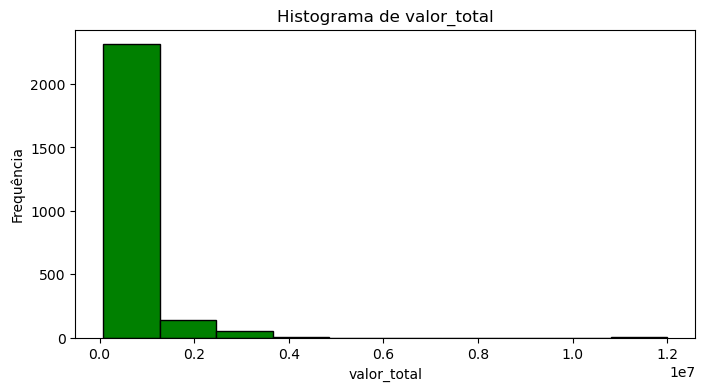

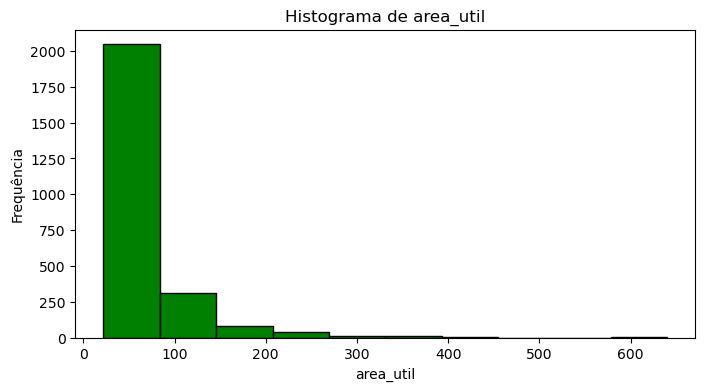

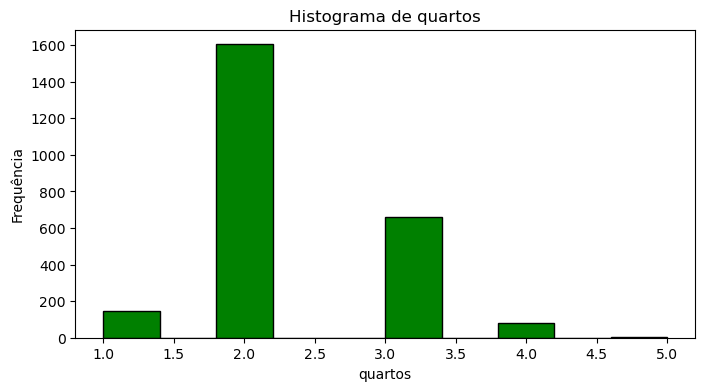

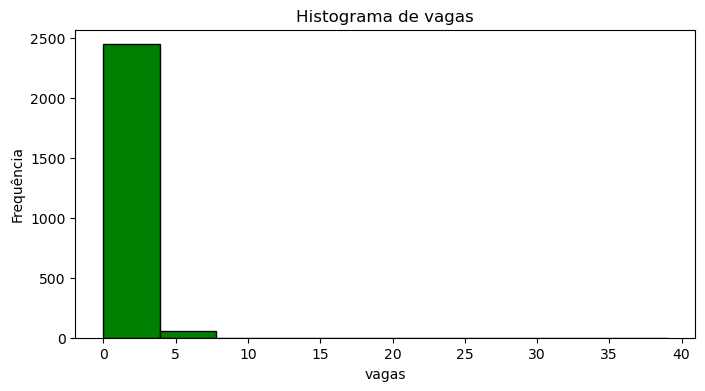

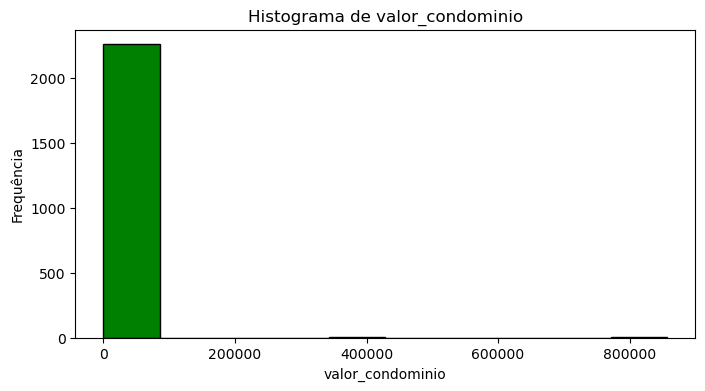

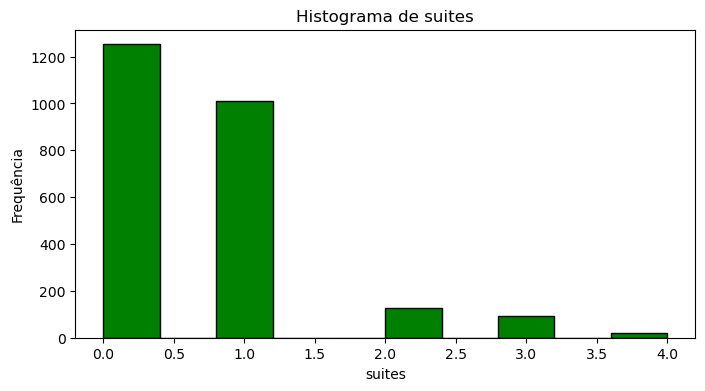

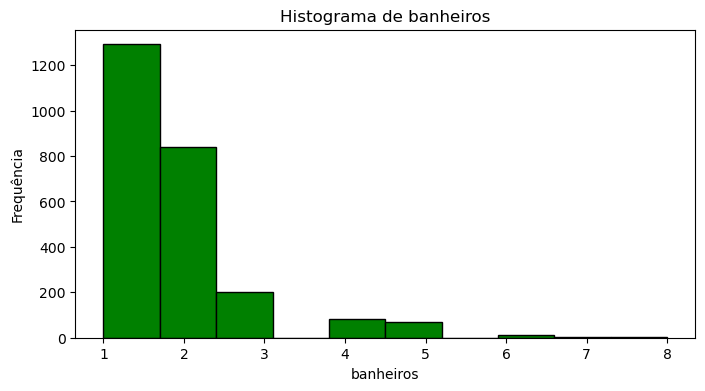

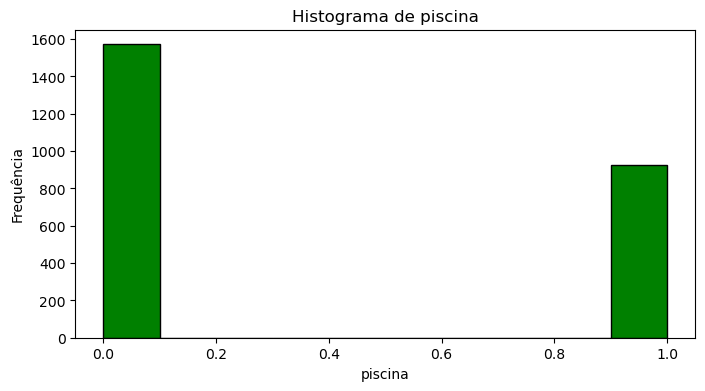

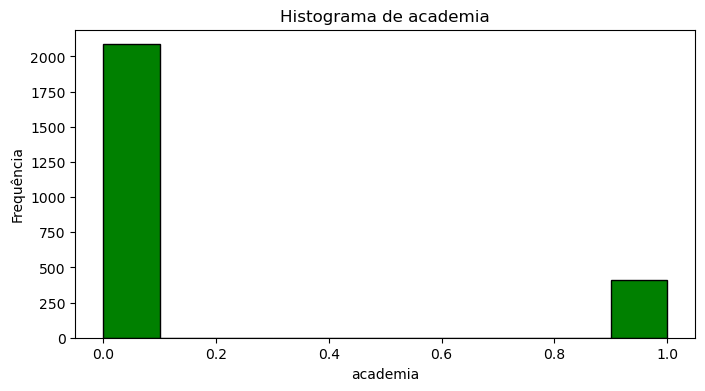

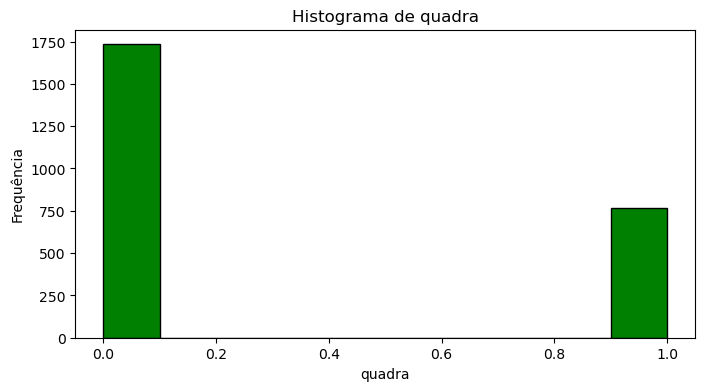

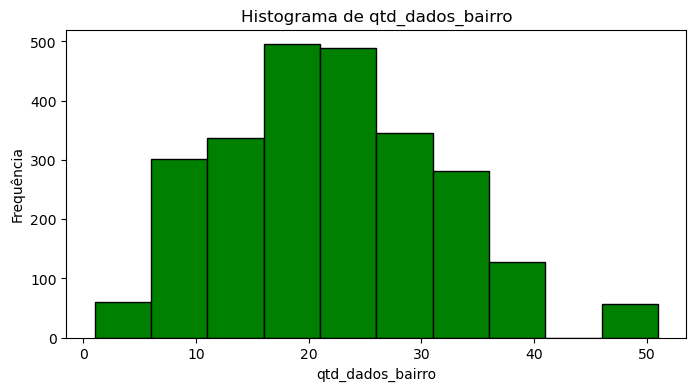

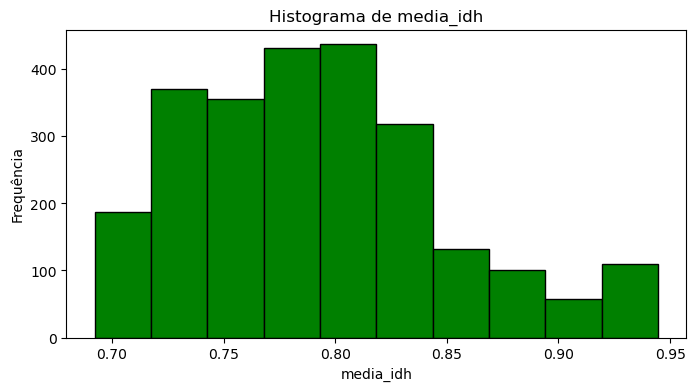

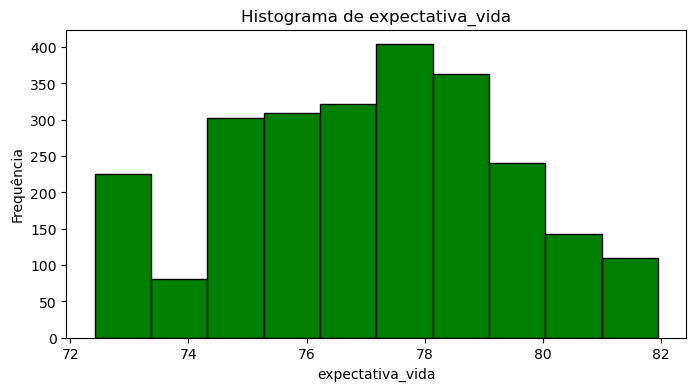

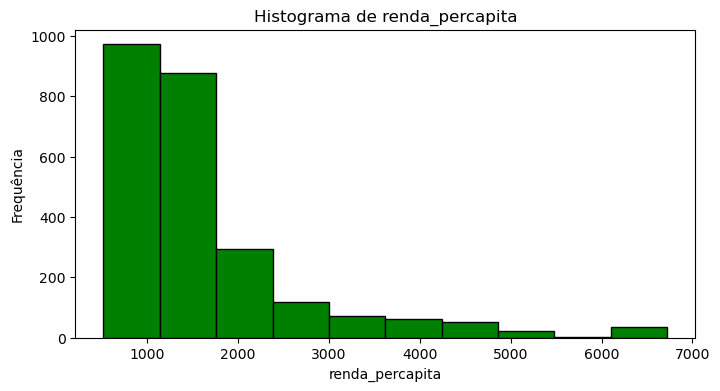

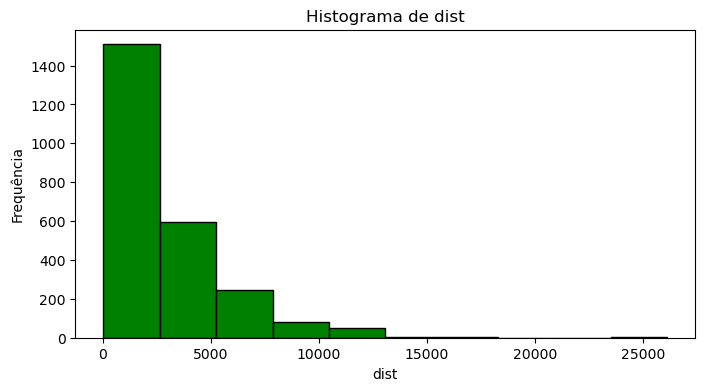

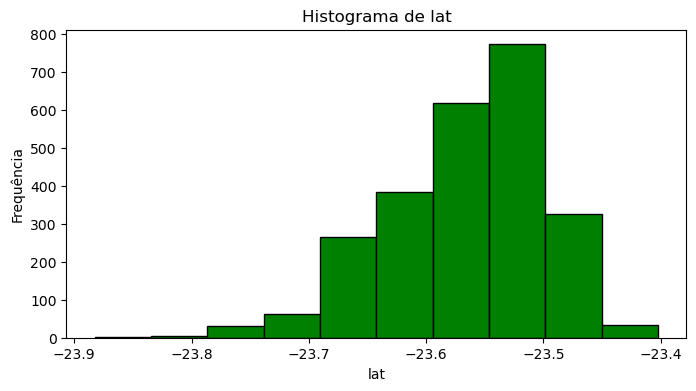

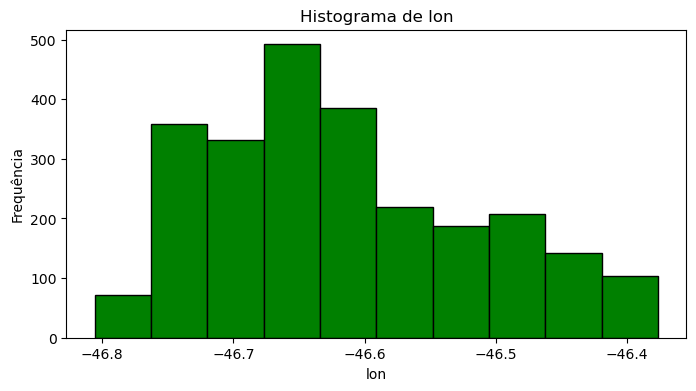

In [6]:
for column in numeric_columns:
    data = df[column].dropna()  
    
    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=10,color='green' ,edgecolor='black')
    plt.title(f"Histograma de {column}")
    plt.xlabel(column)
    plt.ylabel("Frequência")
    plt.show()

<Axes: >

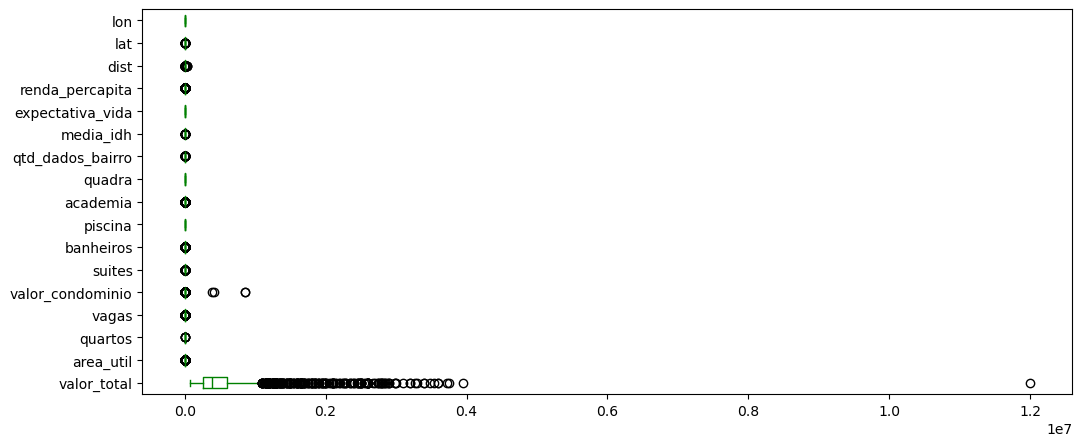

In [7]:
# for column in numeric_columns:  

df[numeric_columns].plot.box(figsize=(12, 5), vert=False, color='green')


Existem muitos outliers na coluna valor_total!

In [8]:
categoric_columns = df.select_dtypes(include=['str']).columns
categoric_columns

Index(['link', 'bairro', 'estacao_prox', 'linha_prox'], dtype='str')

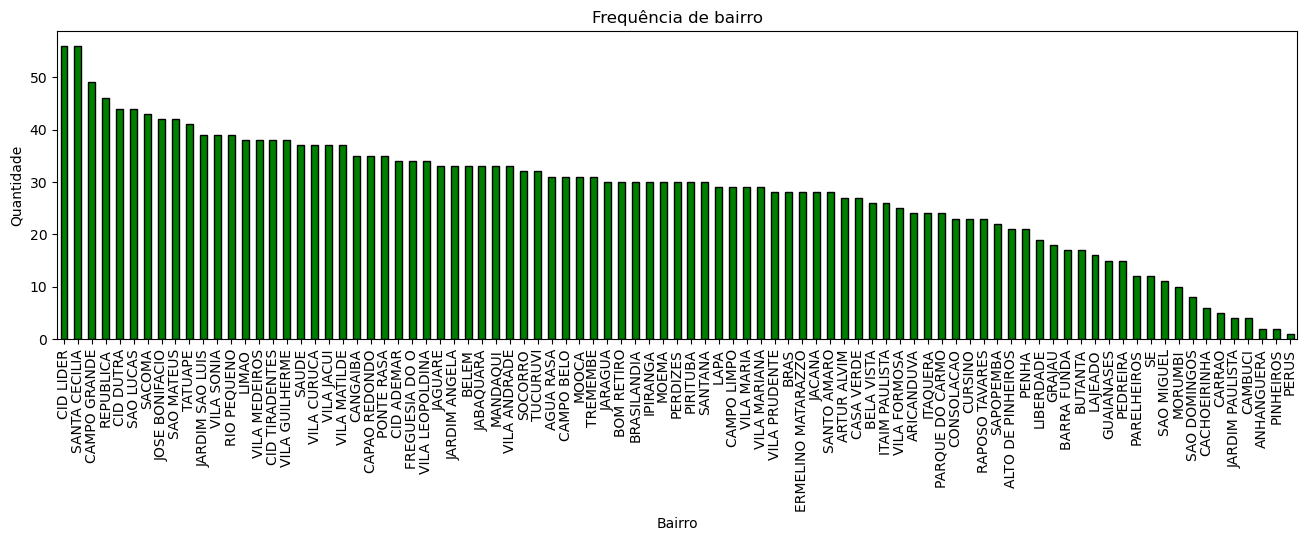

In [9]:
#Bairro 
unique_bairros = df['bairro'].value_counts()
unique_bairros

plt.figure(figsize=(16, 4))
unique_bairros.plot(kind='bar', color='green', edgecolor='black')
plt.title(f"Frequência de bairro")
plt.xlabel("Bairro")
plt.ylabel("Quantidade")
plt.xticks(rotation=90)
plt.show()

Cid lider e Santa Cecilia lideram em quantidade de anúncios no site.

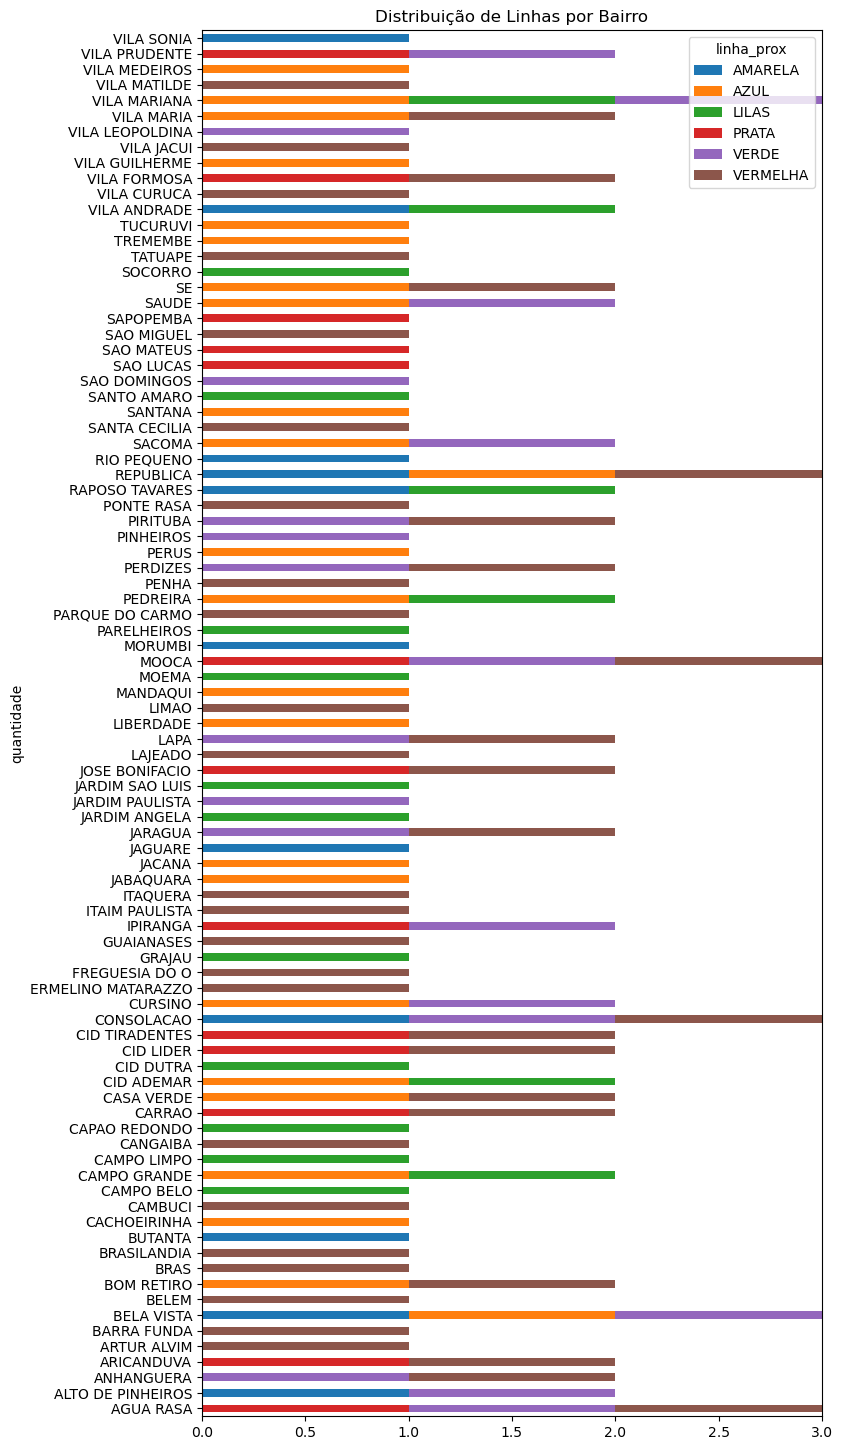

In [10]:
contagem_bairro_linha = (
    df[['bairro', 'linha_prox']]
      .drop_duplicates()
      .groupby(['bairro', 'linha_prox'])
      .size()
      .unstack(fill_value=0)
)
# Linhas próximas por cada bairro:plotei empilhado porque tava muito difícil visualizar os dados sem stacked 
contagem_bairro_linha.plot(kind='barh', stacked=True, figsize=(8, 18))
plt.title('Distribuição de Linhas por Bairro')
plt.ylabel('quantidade')
plt.show()

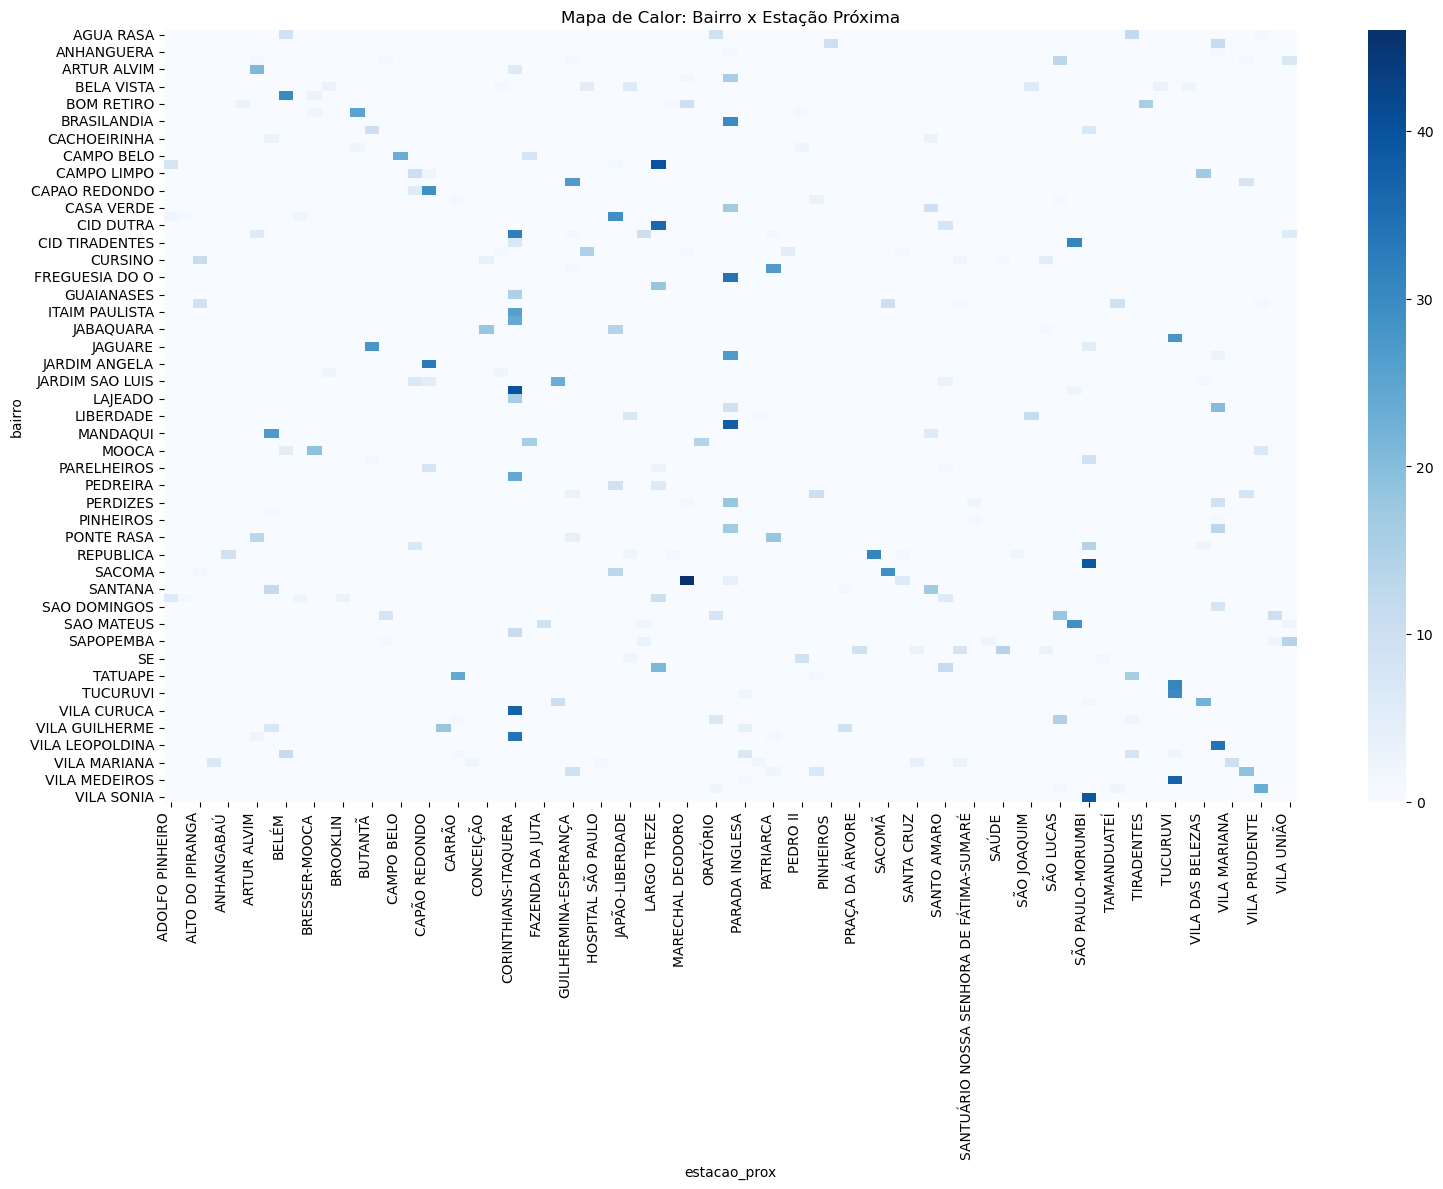

In [11]:
bairros_estacao_prox = pd.crosstab(df['bairro'], df['estacao_prox'])


plt.figure(figsize=(16, 12))
sns.heatmap(bairros_estacao_prox, cmap='Blues', annot=False, fmt='g')

plt.title('Mapa de Calor: Bairro x Estação Próxima')
plt.ylabel('bairro')
plt.xlabel('estacao_prox')

plt.xticks(rotation=90, ha='right')

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Valor Médio Por Bairro'}, xlabel='valor', ylabel='bairro'>

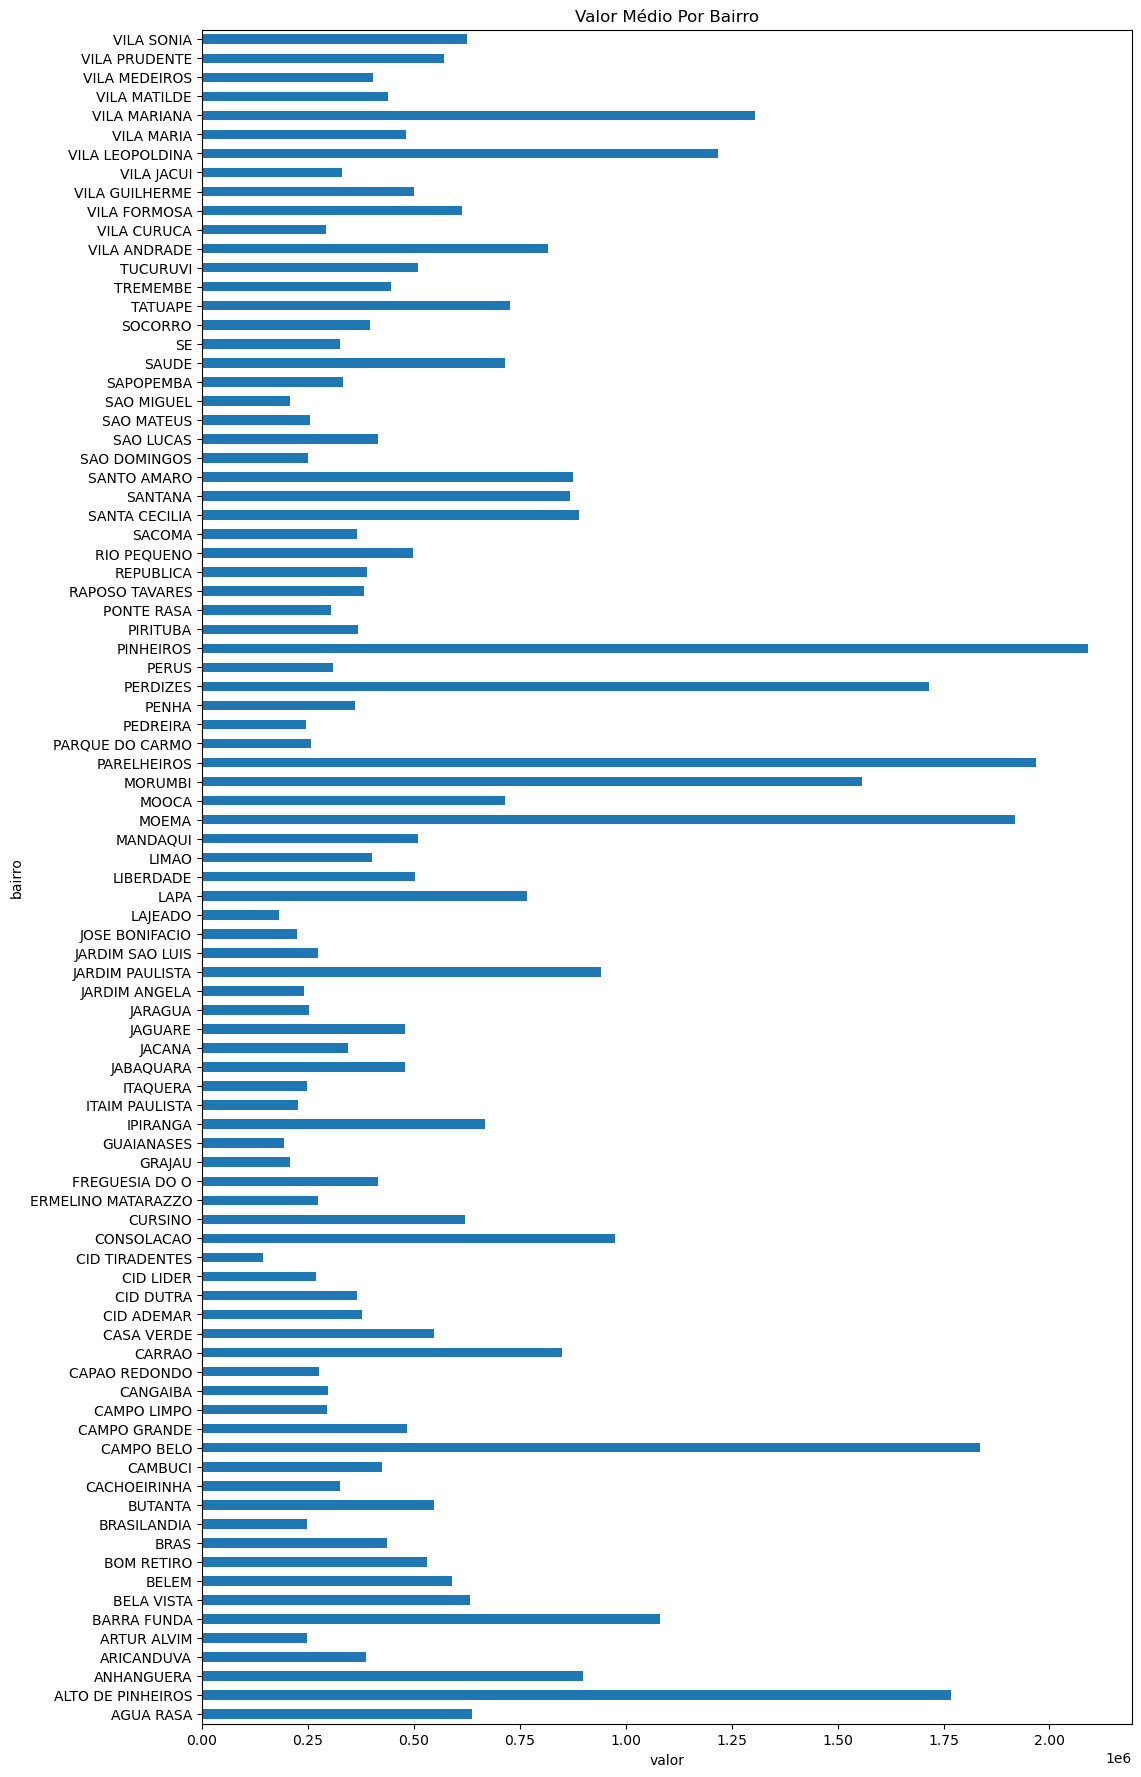

In [12]:
media_valor_total_bairro = df.groupby(['bairro'])['valor_total'].mean()
media_valor_total_bairro

media_valor_total_bairro.plot(kind='barh', figsize=(12, 22), title='Valor Médio Por Bairro', xlabel='valor')


<Axes: title={'center': 'area_util x valor_medio'}, xlabel='valor_medio', ylabel='area_util'>

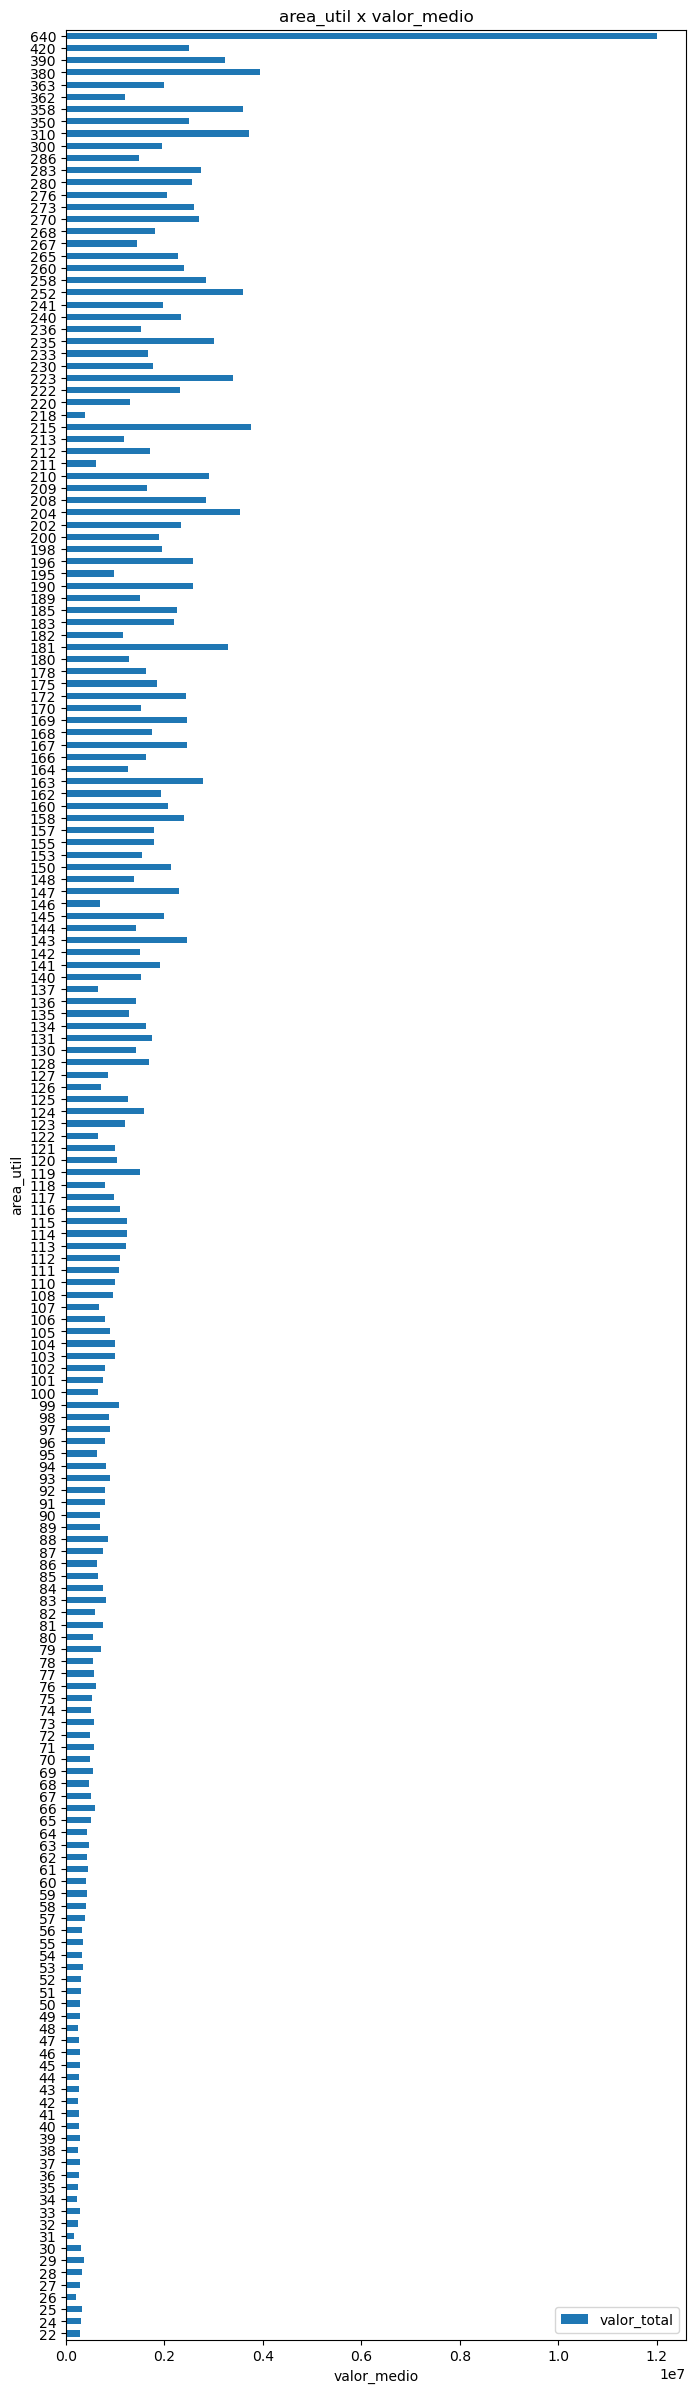

In [13]:
media_valor_area = df.groupby('area_util')[['valor_total']].mean()
media_valor_area
media_valor_area.plot(kind='barh', figsize=(8,30), title='area_util x valor_medio', xlabel='valor_medio', ylabel='area_util') 


<Axes: title={'center': 'Valor Médio do Condomínio x Piscina'}, xlabel='Piscina', ylabel='Valor Médio'>

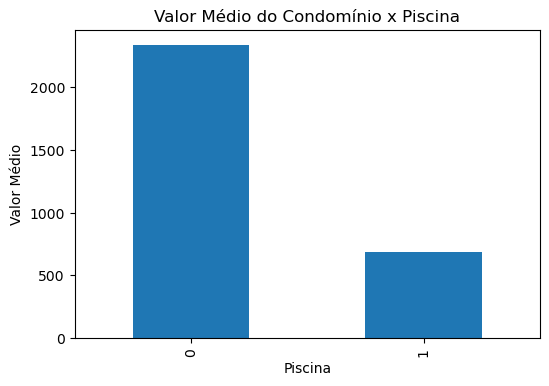

In [14]:
valor_medio_condominio_com_sem_piscina = df.groupby('piscina')['valor_condominio'].mean()
valor_medio_condominio_com_sem_piscina

valor_medio_condominio_com_sem_piscina.plot(
    kind='bar',
    figsize=(6,4),
    title='Valor Médio do Condomínio x Piscina',
    xlabel = 'Piscina',
    ylabel = 'Valor Médio',
)

<Axes: title={'center': 'Valor Médio do Condomínio x Academia'}, xlabel='Academia', ylabel='Valor Médio'>

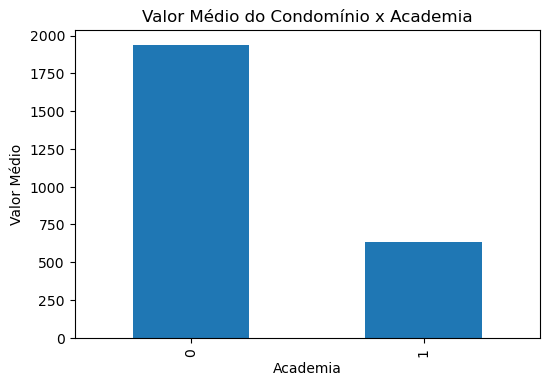

In [15]:
#to-do - media valor condominio por existencia de academia ou não
valor_media_condominio_academia = df.groupby('academia')['valor_condominio'].mean()
valor_media_condominio_academia

valor_media_condominio_academia.plot(
    kind='bar',
    figsize=(6,4),
    title='Valor Médio do Condomínio x Academia',
    xlabel = 'Academia',
    ylabel = 'Valor Médio',
)

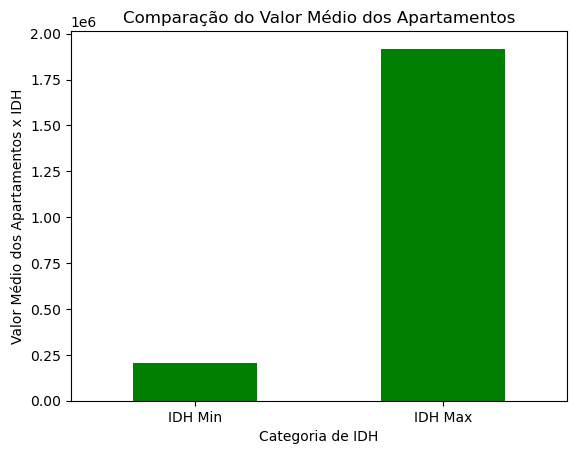

In [16]:
#to-do: comparar idh com max e médio valor dos apartamentos

idh_min = df['media_idh'].min()
idh_max = df['media_idh'].max()

apartamentos_idh_min = df[df['media_idh'] == idh_min]
apartamentos_idh_max = df[df['media_idh'] == idh_max]

apartamentos_min_max_valor = pd.DataFrame({
    'categoria_idh': ['IDH Min', 'IDH Max'],
    'idh': [
        idh_min,
        idh_max
    ],
    'valor_medio_apartamentos': [
        apartamentos_idh_min['valor_total'].mean(),
        apartamentos_idh_max['valor_total'].mean()
    ]
})

apartamentos_min_max_valor.plot(
    x='categoria_idh',
    y='valor_medio_apartamentos',
    kind='bar',
    legend=False,
    color='green'
)

plt.ylabel('Valor Médio dos Apartamentos x IDH')
plt.xlabel('Categoria de IDH')
plt.title('Comparação do Valor Médio dos Apartamentos')
plt.xticks(rotation=0)

plt.show()

<Axes: xlabel='bairro', ylabel='Valor medio'>

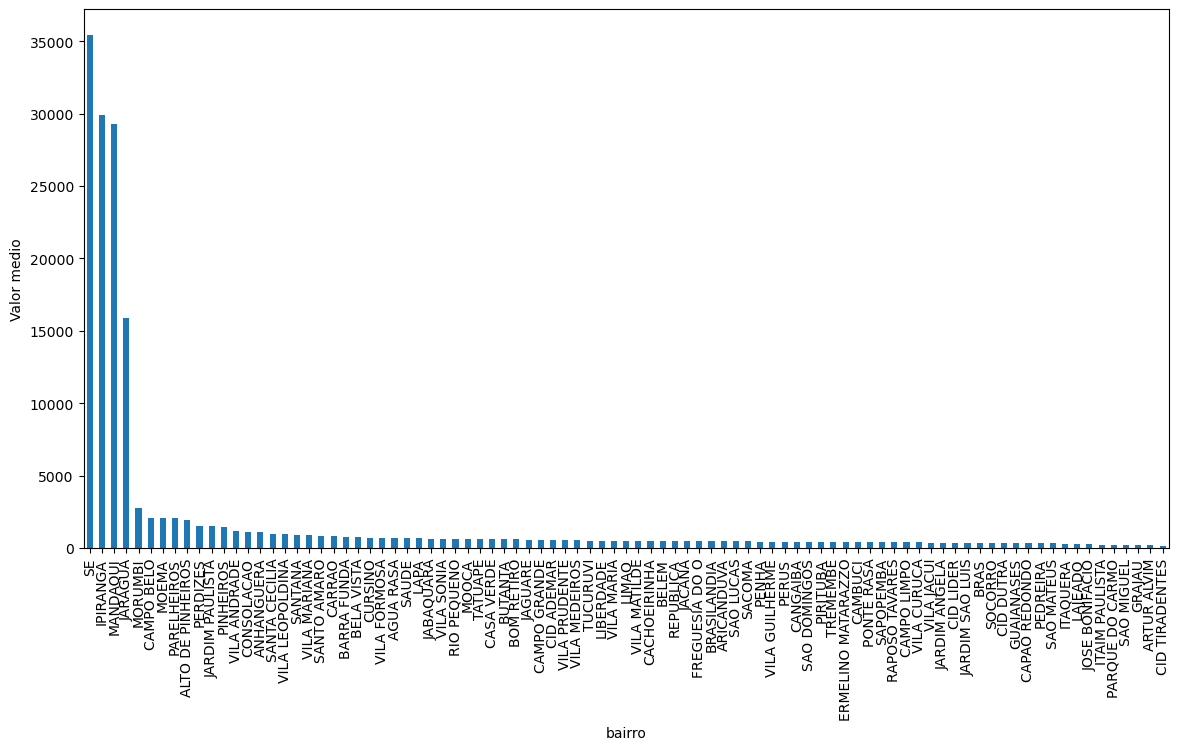

In [17]:
#to-do: verificar valores de condominio por bairros
valores_condominio_por_bairro = (
    df.groupby('bairro')['valor_condominio']
      .mean()
      .sort_values(ascending=False)
)

valores_condominio_por_bairro.plot(
    kind='bar',
    figsize=(14,7),
    ylabel=('Valor medio')
)

<Axes: title={'center': 'Valor Médio do m² por Bairro'}, xlabel='Valor Médio do m²', ylabel='Bairro'>

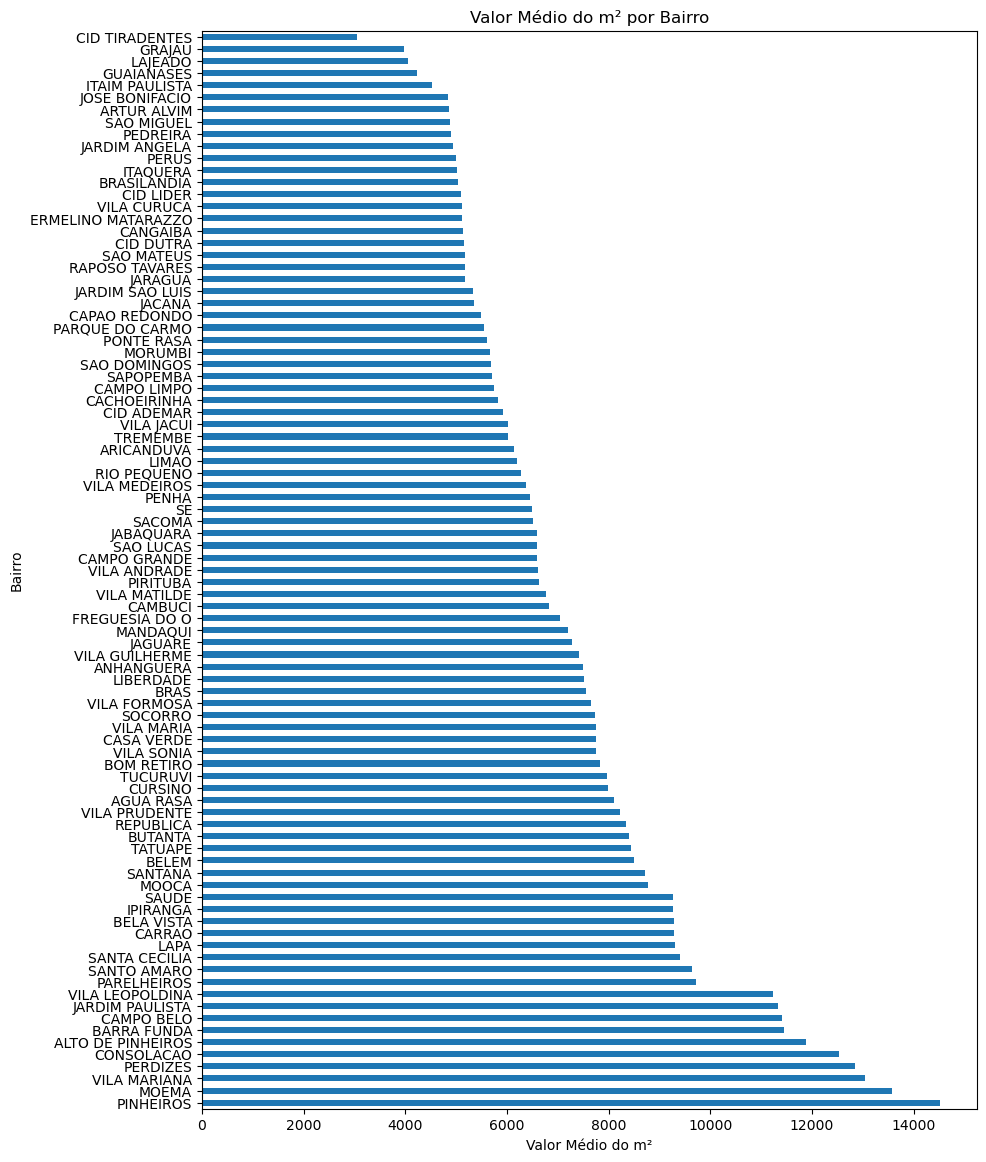

In [18]:
#to-do: verificar a diferença da questão de transporte por bairros com menores e maiores IDH
df['valor_m2'] = df['valor_total'] / df['area_util']

valor_m2_por_bairro = (
    df.groupby('bairro')['valor_m2']
      .mean()
      .sort_values(ascending=False)
)

valor_m2_por_bairro.plot(
    kind='barh',
    figsize=(10,14),
    title = 'Valor Médio do m² por Bairro',
    xlabel = 'Valor Médio do m²',
    ylabel = 'Bairro'
)


<Axes: >

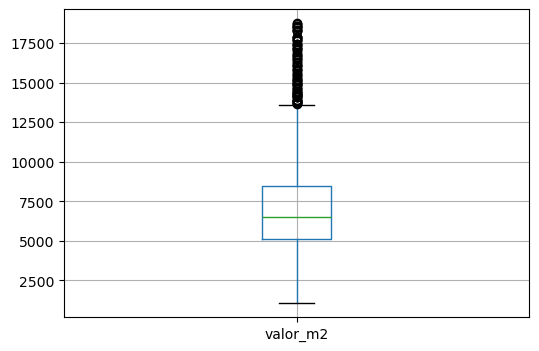

In [19]:
df.boxplot(column='valor_m2', figsize=(6,4))

# Resumo Geral

Ao analisar os dados, foi possível identificar algumas questões interessantes sobre o setor imobiliário no município, desde bairros mais valorizados, diferença de idh entre os bairros, opções de transporte urbano entre outras caractéristicas. 
Por exemplo, o valor médio necessário para ser obter um imóvel é de 548.085,2 reais, porém, provavelmente esse valor foi muito distorcido por causa dos valores destoantes presentes no conjunto de dados (boxplot), esses valores enormes são dos apartamentos de luxo presentes em 
bairros com idh mais alto, como o caso do Bairro Pinheiros que o valor pode ultrapassar os 2.000.000 reais.

Também podemos perceber que os bairros Cid Lider e Santa Cecília são os que possuem mais anúncios de imóveis no site.

Sobre linhas próximas por bairro: Vila Mariana, Republica, Mooca, Consolação, Bela Vista e Água Rasa lideram com 4 linhas.

Sobre estações próximas por bairro, é interessante notar que os bairros mais ricos não possuem tantas estações.
Cid Tiradentes é o bairro com valor médio mais baixo enquanto Pinheiros é o maior.

Também é possível analisar como a existência de academia, piscinas e vagas influenciam o valor do Condomínio. Vide que o valor médio de condominio com piscina e sem piscina são respectivamente de 2342.442 reais e 687.37 reais. Com ou sem academia são respectivamente de 
1940.45 reais e 632.42 reais. 

Sobre a relação entre valor médio e IDH, obviamente quanto maior o IDH maior o valor médio do apartamento.

Se é o bairro com valor de condominio mais alto.

Sobre o valor médio por metro quadrado: Pinheiros lidera ultrapassando os 14.000 reais por m². Ao plotar o boxplot do valor x m², conseguimos visualizar esses outliers presentes em nossos dados.